In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install dependencies
!pip install -q torchvision torchaudio
!pip install -q tqdm matplotlib scipy pillow
!pip install -q pytorch-fid
!pip install -q tensorboard

print("Dependencies have been installed")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dependencies have been installed


In [5]:
import sys
import os
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from tqdm import tqdm
import pickle
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from scipy import linalg
import copy
from collections import defaultdict
import time
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.0f} GB")


Using device: cuda
GPU: NVIDIA L4
Memory: 24 GB


In [6]:
class myconfig:

    # === TASK 1: Training ===
    # 2-class selection
    selected_classes = [0, 1]
    class_names = ['airplane', 'automobile']

    # Model (aligned with repo)
    img_channels = 3
    base_channels = 128
    time_emb_dim = 256
    num_blocks = [2, 2, 2, 2]
    attention_resolutions = [16, 8]

    # Training
    batch_size = 128
    learning_rate = 2e-4
    weight_decay = 1e-4
    gradient_clip = 1.0
    ema_decay = 0.9999

    # Train for 200k steps with checkpoints every 20k
    num_steps = 100100
    checkpoint_every = 20000  # Save at 20k, 40k, 60k, ..., 200k

    # FID evaluation at each checkpoint
    fid_num_samples = 2000  # 2k validation images
    fid_batch_size = 100

    # Optimizer
    adam_betas = (0.9, 0.999)

    # ODE solvers to compare
    solvers = ['euler', 'heun', 'rk4']
    num_steps_list = [10, 20, 50, 100, 500, 1000]

    # === PATHS ===
    save_dir = '/content/drive/MyDrive/FM_coursework'
    checkpoint_dir = os.path.join(save_dir, 'checkpoints')
    validation_dir = os.path.join(save_dir, 'validation_images')
    results_dir = os.path.join(save_dir, 'results')

config = myconfig()
os.makedirs(config.checkpoint_dir, exist_ok=True)
os.makedirs(config.validation_dir, exist_ok=True)
os.makedirs(config.results_dir, exist_ok=True)

print(f"  Config initialized")
print(f"  Classes: {config.class_names}")
print(f"  Training steps: {config.num_steps}")
print(f"  Checkpoint interval: {config.checkpoint_every}")
print(f"  FID samples: {config.fid_num_samples}")


  Config initialized
  Classes: ['airplane', 'automobile']
  Training steps: 100100
  Checkpoint interval: 20000
  FID samples: 2000


In [7]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        # Ensure time is 1-D: [B]
        if time.dim() > 1:
            time = time.view(time.size(0))

        device = time.device
        half_dim = self.dim // 2
        scale = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -scale)  # [half_dim]
        emb = time[:, None] * emb[None, :]                               # [B, half_dim]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)                  # [B, dim]
        return emb

class AttentionBlock(nn.Module):
    def __init__(self, channels, num_heads=8):
        super().__init__()
        self.channels = channels
        self.num_heads = num_heads
        self.norm = nn.GroupNorm(32, channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)

    # Modified to accept t_emb but not use it, for consistent calling in UNet
    def forward(self, x, t_emb=None): # Added t_emb=None
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, C, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]

        q = q.reshape(B * self.num_heads, C // self.num_heads, H * W)
        k = k.reshape(B * self.num_heads, C // self.num_heads, H * W)
        v = v.reshape(B * self.num_heads, C // self.num_heads, H * W)

        scale = (C // self.num_heads) ** -0.5
        attn = torch.bmm(q.transpose(-2, -1), k) * scale
        attn = F.softmax(attn, dim=-1)
        out = torch.bmm(attn, v.transpose(-2, -1))
        out = out.reshape(B, C, H, W)
        out = self.proj(out)

        return x + out

print("Attention blocks defined")

Attention blocks defined


In [8]:
# Defining Res block
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim, dropout=0.1):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels

        self.norm1 = nn.GroupNorm(32, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.time_proj = nn.Linear(time_emb_dim, out_channels)
        self.norm2 = nn.GroupNorm(32, out_channels)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.skip = nn.Identity()

    def forward(self, x, t_emb):
        h = F.silu(self.norm1(x))
        h = self.conv1(h)
        h = h + self.time_proj(F.silu(t_emb))[:, :, None, None]
        h = F.silu(self.norm2(h))
        h = self.dropout(h)
        h = self.conv2(h)
        return h + self.skip(x)

print("ResBlock defined")


ResBlock defined


In [9]:
class UNet(nn.Module):
    def __init__(self, img_channels=3, base_channels=128, time_emb_dim=256,
                 num_blocks=[2, 2, 2, 2], attention_resolutions=[16, 8]):
        super().__init__()

        self.img_channels = img_channels
        self.base_channels = base_channels
        self.time_emb_dim = time_emb_dim

        # Time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )

        # Initial conv
        self.initial_conv = nn.Conv2d(img_channels, base_channels, 3, padding=1)

        # Channel scaling
        channels = [base_channels * (2 ** i) for i in range(len(num_blocks))]

        # Encoder
        self.encoder = nn.ModuleList()
        for i, num_block in enumerate(num_blocks):
            blocks = nn.ModuleList()
            current_in_channels_for_stage = base_channels if i == 0 else channels[i-1]
            target_out_channels_for_stage = channels[i]

            for j in range(num_block):
                in_ch_block = current_in_channels_for_stage if j == 0 else target_out_channels_for_stage
                out_ch_block = target_out_channels_for_stage
                blocks.append(ResBlock(in_ch_block, out_ch_block, time_emb_dim))
                if 32 // (2 ** i) in attention_resolutions:
                    blocks.append(AttentionBlock(out_ch_block))
            self.encoder.append(blocks)

        # Bottleneck
        self.bottleneck = nn.ModuleList()
        bottleneck_ch = channels[-1]
        self.bottleneck.append(ResBlock(bottleneck_ch, bottleneck_ch, time_emb_dim))
        self.bottleneck.append(AttentionBlock(bottleneck_ch))
        self.bottleneck.append(ResBlock(bottleneck_ch, bottleneck_ch, time_emb_dim))

        # Decoder
        self.decoder = nn.ModuleList()
        for i_rev in reversed(range(len(num_blocks))):
            blocks = nn.ModuleList()
            current_stage_channel = channels[i_rev]
            for j in range(num_blocks[i_rev] + 1):
                if j == 0:
                    if i_rev == len(num_blocks) - 1: # Smallest feature map stage
                        in_ch_block = current_stage_channel * 2 # From bottleneck output + skip connection
                    else:
                        # From previous decoder stage output + current skip connection
                        in_ch_block = current_stage_channel + channels[i_rev + 1]
                else:
                    in_ch_block = current_stage_channel
                out_ch_block = current_stage_channel
                blocks.append(ResBlock(in_ch_block, out_ch_block, time_emb_dim))
                if 32 // (2 ** i_rev) in attention_resolutions:
                    blocks.append(AttentionBlock(out_ch_block))
            self.decoder.append(blocks)

        # Output
        self.final_norm = nn.GroupNorm(32, base_channels)
        self.final_conv = nn.Conv2d(base_channels, img_channels, 3, padding=1)

        self.downsample = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

    def forward(self, x, t):
        if t.dim()==2 and t.size(1)==1:
          t = t[:,0]
        elif t.dim() > 1:
          raise ValueError(f"Time tensor t has wrong shape: {t.shape}")
        t_emb = self.time_mlp(t)
        h = self.initial_conv(x)
        encoder_outputs = [h]

        for i, encoder_block_list in enumerate(self.encoder):
            for block in encoder_block_list:
                h = block(h, t_emb) # Always pass t_emb
            encoder_outputs.append(h)
            h = self.downsample(h)

        for block in self.bottleneck:
            h = block(h, t_emb) # Always pass t_emb

        for i, decoder_block_list in enumerate(self.decoder):
            h = self.upsample(h)
            # Fix: Corrected indexing for encoder_outputs to match spatial dimensions
            h = torch.cat([h, encoder_outputs[len(self.encoder) - i]], dim=1)
            for block in decoder_block_list:
                h = block(h, t_emb) # Always pass t_emb

        h = F.silu(self.final_norm(h))
        h = self.final_conv(h)

        return h

# Test init
model = UNet()
total_params = sum(p.numel() for p in model.parameters())
print(f"U-Net initialized: {total_params:,} parameters")
del model
torch.cuda.empty_cache()

U-Net initialized: 190,721,923 parameters


In [10]:
class FlowMatching:
    def __init__(self, model, device='cuda', config=None):
        self.model = model.to(device)
        self.device = device
        self.config = config or myconfig()

        # CRITICAL: EMA model
        self.ema_model = copy.deepcopy(self.model)
        for param in self.ema_model.parameters():
            param.requires_grad = False

    def update_ema(self):
        """Update EMA after each step"""
        ema_decay = self.config.ema_decay
        with torch.no_grad():
            for ema_param, param in zip(self.ema_model.parameters(),
                                       self.model.parameters()):
                ema_param.data.mul_(ema_decay).add_(param.data, alpha=1 - ema_decay)

    def compute_loss(self, x0, x1):
        batch_size = x0.shape[0]
        t = torch.rand(batch_size, device=self.device)
        t_expanded = t[:, None, None, None]
        x_t = t_expanded * x1 + (1 - t_expanded) * x0
        v_t = x1 - x0
        v_pred = self.model(x_t, t)
        loss = F.mse_loss(v_pred, v_t)
        return loss

    @torch.no_grad()
    def sample_euler(self, batch_size, num_steps=100, img_size=32, channels=3):
        """Euler method"""
        self.ema_model.eval()
        x = torch.randn(batch_size, channels, img_size, img_size, device=self.device)
        dt = 1.0 / num_steps

        for i in range(num_steps):
            t = torch.ones(batch_size, device=self.device) * (i * dt)
            v = self.ema_model(x, t)
            x = x + v * dt

        return x.clamp(-1, 1)

    @torch.no_grad()
    def sample_heun(self, batch_size, num_steps=100, img_size=32, channels=3):
        """Heun's method (2nd order)"""
        self.ema_model.eval()
        x = torch.randn(batch_size, channels, img_size, img_size, device=self.device)
        dt = 1.0 / num_steps

        for i in range(num_steps):
            t = torch.ones(batch_size, device=self.device) * (i * dt)
            t_next = torch.ones(batch_size, device=self.device) * ((i + 1) * dt)

            v1 = self.ema_model(x, t)
            x_pred = x + v1 * dt
            v2 = self.ema_model(x_pred, t_next)
            x = x + (v1 + v2) * dt / 2

        return x.clamp(-1, 1)

    @torch.no_grad()
    def sample_rk4(self, batch_size, num_steps=100, img_size=32, channels=3):
        """RK4 method (4th order)"""
        self.ema_model.eval()
        x = torch.randn(batch_size, channels, img_size, img_size, device=self.device)
        dt = 1.0 / num_steps

        for i in range(num_steps):
            t = torch.ones(batch_size, device=self.device) * (i * dt)

            k1 = self.ema_model(x, t)
            t_mid = t + dt / 2
            k2 = self.ema_model(x + dt * k1 / 2, t_mid)
            k3 = self.ema_model(x + dt * k2 / 2, t_mid)
            t_end = t + dt
            k4 = self.ema_model(x + dt * k3, t_end)

            x = x + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

        return x.clamp(-1, 1)

    def sample(self, batch_size, num_steps=100, method='euler'):
        """Generic sampling"""
        if method == 'euler':
            return self.sample_euler(batch_size, num_steps)
        elif method == 'heun':
            return self.sample_heun(batch_size, num_steps)
        elif method == 'rk4':
            return self.sample_rk4(batch_size, num_steps)
        else:
            raise ValueError(f"Unknown method: {method}")

print("FlowMatching class defined")

FlowMatching class defined


In [11]:
class FIDCalculator:
    def __init__(self, device='cuda'):
        self.inception = models.inception_v3(pretrained=True, transform_input=False)
        self.inception.fc = nn.Identity()
        self.inception = self.inception.to(device).eval()
        self.device = device

    @torch.no_grad()
    def get_features(self, images, batch_size=config.fid_batch_size):
        # Ensure images are on CPU before batching to avoid multiple GPU transfers
        images_cpu = images.cpu()
        all_features = []

        for i in range(0, images_cpu.shape[0], batch_size):
            batch_images = images_cpu[i:i + batch_size].to(self.device)
            batch_images = F.interpolate(batch_images, size=(299, 299), mode='bilinear', align_corners=False)
            batch_images = (batch_images + 1) / 2  # [-1, 1] → [0, 1]
            mean = torch.tensor([0.485, 0.456, 0.406], device=self.device).view(1, 3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225], device=self.device).view(1, 3, 1, 1)
            batch_images = (batch_images - mean) / std
            features = self.inception(batch_images)
            all_features.append(features.cpu().numpy())
            torch.cuda.empty_cache() # Clear cache after each batch

        return np.concatenate(all_features, axis=0)

    def compute_fid(self, generated_images, real_images):
        gen_features = self.get_features(generated_images)
        real_features = self.get_features(real_images)

        gen_mean = np.mean(gen_features, axis=0)
        gen_cov = np.cov(gen_features.T)

        real_mean = np.mean(real_features, axis=0)
        real_cov = np.cov(real_features.T)

        mean_diff = np.sum((gen_mean - real_mean) ** 2)
        cov_sqrt = linalg.sqrtm(gen_cov @ real_cov)

        if np.iscomplexobj(cov_sqrt):
            cov_sqrt = np.real(cov_sqrt)

        fid = mean_diff + np.trace(gen_cov + real_cov - 2 * cov_sqrt)

        return fid

print("FIDCalculator defined")

FIDCalculator defined


In [12]:
class CIFAR10Dataset(Dataset):
    def __init__(self, data, labels):
        self.data = data.reshape(-1, 3, 32, 32).astype(np.float32) / 255.0
        self.data = (self.data - 0.5) / 0.5  # [-1, 1]
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.from_numpy(self.data[idx]), self.labels[idx]

def unpickle(file):
    with open(file, 'rb') as f:
        return pickle.load(f, encoding='bytes')

def load_cifar10_subset(cifar_path, selected_classes):
    """Load 2-class subset (coursework requirement)"""
    train_data = []
    train_labels = []
    for i in range(1, 6):
        batch = unpickle(os.path.join(cifar_path, f'data_batch_{i}'))
        train_data.append(batch[b'data'])
        train_labels.extend(batch[b'labels'])

    train_data = np.vstack(train_data)
    train_labels = np.array(train_labels)

    # Filter for selected classes
    mask = np.isin(train_labels, selected_classes)
    train_data = train_data[mask]
    train_labels = train_labels[mask]

    # Remap labels
    label_map = {selected_classes[i]: i for i in range(len(selected_classes))}
    train_labels = np.array([label_map[l] for l in train_labels])

    # Test data
    test_batch = unpickle(os.path.join(cifar_path, 'test_batch'))
    test_data = test_batch[b'data']
    test_labels = np.array(test_batch[b'labels'])

    mask = np.isin(test_labels, selected_classes)
    test_data = test_data[mask]
    test_labels = test_labels[mask]
    test_labels = np.array([label_map[l] for l in test_labels])

    return train_data, train_labels, test_data, test_labels

print(" Dataset classes defined")


 Dataset classes defined


In [11]:
def train_flow_matching(config=config):
    """Main training function"""

    # Load data
    print(f"Loading CIFAR-10 subset: {config.class_names}...")
    cifar_path = '/content/drive/MyDrive/cifar-10-batches-py'
    train_data, train_labels, test_data, test_labels = load_cifar10_subset(
        cifar_path, config.selected_classes
    )

    train_dataset = CIFAR10Dataset(train_data, train_labels)
    test_dataset = CIFAR10Dataset(test_data, test_labels)

    train_loader = DataLoader(train_dataset, batch_size=config.batch_size,
                             shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=config.batch_size,
                            shuffle=False, num_workers=2, pin_memory=True)

    print(f" Train: {len(train_dataset)}, Test: {len(test_dataset)}")

    # Model
    print("Building U-Net...")
    model = UNet(
        img_channels=config.img_channels,
        base_channels=config.base_channels,
        time_emb_dim=config.time_emb_dim,
        num_blocks=config.num_blocks,
        attention_resolutions=config.attention_resolutions
    )

    total_params = sum(p.numel() for p in model.parameters())
    print(f" Model: {total_params:,} parameters")

    fm = FlowMatching(model, device=device, config=config)

    # Optimizer
    optimizer = optim.Adam(fm.model.parameters(),
                          lr=config.learning_rate,
                          betas=config.adam_betas,
                          weight_decay=config.weight_decay)

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.num_steps)

    # FID calculator
    fid_calc = FIDCalculator(device=device)

    # Save validation images once
    val_data_for_fid = test_data[:config.fid_num_samples]
    np.save(os.path.join(config.validation_dir, 'val_images.npy'), val_data_for_fid)

    # Training
    print(f"Starting training for {config.num_steps} steps...")
    history = {
        'loss': [],
        'iteration': [],
        'wallclock': [],
        'fid': defaultdict(list),
    }

    iteration = 0
    start_time = time.time()
    data_iter = iter(train_loader)

    while iteration < config.num_steps:
        try:
            x, _ = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader)
            x, _ = next(data_iter)

        x0 = torch.randn_like(x).to(device)
        x1 = x.to(device)

        # Forward
        loss = fm.compute_loss(x0, x1)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(fm.model.parameters(), config.gradient_clip)
        optimizer.step()
        scheduler.step()

        # Update EMA
        fm.update_ema()

        elapsed = time.time() - start_time
        history['loss'].append(loss.item())
        history['iteration'].append(iteration)
        history['wallclock'].append(elapsed)

        if iteration % 100 == 0:
            lr = optimizer.param_groups[0]['lr']
            print(f"Step {iteration:6d} | Loss: {loss.item():.4f} | LR: {lr:.2e} | Time: {elapsed/3600:.1f}h")

        #  Save checkpoint + compute FID every 20k steps
        if (iteration + 1) % config.checkpoint_every == 0:
            ckpt_path = os.path.join(config.checkpoint_dir, f'FM_step{iteration+1}.pt')
            torch.save(fm.ema_model.state_dict(), ckpt_path)
            print(f" Saved checkpoint: {ckpt_path}")

            # Compute FID on 2k validation images
            print(f"  Computing FID at step {iteration+1}...")
            all_gen = []
            for _ in tqdm(range(config.fid_num_samples // config.fid_batch_size)):
                gen = fm.sample_euler(batch_size=config.fid_batch_size, num_steps=50)
                all_gen.append(gen.cpu())
                torch.cuda.empty_cache()

            gen_samples = torch.cat(all_gen, dim=0)
            val_samples = torch.from_numpy(val_data_for_fid).float()
            val_samples = (val_samples.reshape(-1, 3, 32, 32) / 255.0 - 0.5) / 0.5

            fid_score = fid_calc.compute_fid(gen_samples.to(device), val_samples.to(device))
            del gen_samples, val_samples
            torch.cuda.empty_cache()
            history['fid']['euler_50'].append(fid_score)
            print(f"  FID (Euler 50 steps): {fid_score:.2f}")

        iteration += 1

    print(f"\n Training complete! Total time: {(time.time() - start_time)/3600:.1f}h")

    # Save final model
    torch.save(fm.ema_model.state_dict(), os.path.join(config.checkpoint_dir, 'FM_final.pt'))
    print(f" Final model saved")

    return history, fm, test_loader, fid_calc

# START TRAINING
history, fm, test_loader, fid_calc = train_flow_matching()

Loading CIFAR-10 subset: ['airplane', 'automobile']...


KeyboardInterrupt: 

In [ ]:
# ============================================================
# Resume training from latest FM_stepXXXX.pt checkpoint
# ============================================================
import re
from glob import glob

def resume_from_latest_ema(config=config):
    """
    Resume training from the latest EMA checkpoint FM_stepXXXX.pt.
    Uses the same training loop structure as train_flow_matching,
    but starts from the iteration encoded in the checkpoint name.
    """

    # 1. Find latest EMA checkpoint
    pattern = os.path.join(config.checkpoint_dir, "FM_step*.pt")
    ckpts = glob(pattern)
    if not ckpts:
        print(f"No EMA checkpoints found in {config.checkpoint_dir}")
        return None, None, None, None

    def extract_step(path):
        match = re.search(r'FM_step(\d+)\.pt', path)
        return int(match.group(1)) if match else 0

    latest_ckpt = max(ckpts, key=extract_step)
    start_iter = extract_step(latest_ckpt)

    print(f"Resuming from: {latest_ckpt}")
    print(f"Starting from step: {start_iter}")

    # 2. Load data
    print(f"Loading CIFAR-10 subset: {config.class_names}...")
    cifar_path = '/content/drive/MyDrive/cifar-10-batches-py'
    train_data, train_labels, test_data, test_labels = load_cifar10_subset(
        cifar_path, config.selected_classes
    )
    print(f"Train: {len(train_labels)}, Test: {len(test_labels)}")

    train_dataset = CIFAR10Dataset(train_data, train_labels)
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size,
                             shuffle=True, num_workers=2, pin_memory=True)

    test_dataset = CIFAR10Dataset(test_data, test_labels)
    test_loader = DataLoader(test_dataset, batch_size=config.fid_batch_size,
                            shuffle=False)

    # 3. Build model
    print("Building U-Net...")
    model = UNet(
        img_channels=config.img_channels,
        base_channels=config.base_channels,
        time_emb_dim=config.time_emb_dim,
        num_blocks=config.num_blocks,
        attention_resolutions=config.attention_resolutions
    )
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Model: {total_params:,} parameters")

    # 4. Initialize FlowMatching
    fm = FlowMatching(model, device=device, config=config)

    # 5. Load EMA weights into both ema_model and main model
    ema_state = torch.load(latest_ckpt, map_location=device)
    fm.ema_model.load_state_dict(ema_state)
    fm.model.load_state_dict(ema_state)  # Start training from EMA weights

    # 6. Setup optimizer and scheduler (recreate from scratch)
    optimizer = optim.AdamW(
        fm.model.parameters(),
        lr=config.learning_rate,
        weight_decay=config.weight_decay,
        betas=config.adam_betas
    )

    # Cosine annealing scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=config.num_steps,
        eta_min=0
    )

    # Fast-forward scheduler to current step
    for _ in range(start_iter):
        scheduler.step()

    # 7. Initialize FID calculator
    fid_calc = FIDCalculator(device=device)

    # 8. Training history
    history = {
        'loss': [],
        'iteration': [],
        'wallclock': [],
        'fid': defaultdict(list),
    }

    # 9. Resume training loop
    print(f"Resuming training from step {start_iter} to {config.num_steps}...")
    fm.model.train()

    train_iter = iter(train_loader)
    start_time = time.time()

    for step in range(start_iter, config.num_steps):
        # Get batch
        try:
            x1, _ = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            x1, _ = next(train_iter)

        x1 = x1.to(device)
        x0 = torch.randn_like(x1)

        # Forward pass
        loss = fm.compute_loss(x0, x1)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(fm.model.parameters(), config.gradient_clip)
        optimizer.step()
        scheduler.step()

        # Update EMA
        fm.update_ema()

        # Log
        history['loss'].append(loss.item())
        history['iteration'].append(step) # Store current step
        history['wallclock'].append(time.time() - start_time) # Store elapsed time

        if step % 100 == 0:
            elapsed = (time.time() - start_time) / 3600
            lr = optimizer.param_groups[0]['lr']
            print(f"Step {step} | Loss: {loss.item():.4f} | LR: {lr:.2e} | Time: {elapsed:.1f}h")

        # Checkpoint and FID
        if (step + 1) % config.checkpoint_every == 0:
            ckpt_path = os.path.join(config.checkpoint_dir, f"FM_step{step+1}.pt")
            torch.save(fm.ema_model.state_dict(), ckpt_path)
            print(f"Saved checkpoint: {ckpt_path}")

            # Compute FID
            print(f"Computing FID at step {step+1}...")
            fm.ema_model.eval()

            # Ensure val_data_for_fid is loaded if not already in context
            val_data_for_fid_path = os.path.join(config.validation_dir, 'val_images.npy')
            if not os.path.exists(val_data_for_fid_path):
                print("  Validation data for FID not found. Loading again...")
                _, _, temp_test_data, _ = load_cifar10_subset(cifar_path, config.selected_classes)
                val_data_for_fid = temp_test_data[:config.fid_num_samples]
                np.save(val_data_for_fid_path, val_data_for_fid)
            else:
                val_data_for_fid = np.load(val_data_for_fid_path)

            val_samples_tensor = torch.from_numpy(val_data_for_fid).float()
            val_samples_tensor = (val_samples_tensor.reshape(-1, 3, 32, 32) / 255.0 - 0.5) / 0.5

            all_gen = []
            for _ in tqdm(range(config.fid_num_samples // config.fid_batch_size)):
                gen = fm.sample_euler(batch_size=config.fid_batch_size, num_steps=50)
                all_gen.append(gen.cpu())
                torch.cuda.empty_cache()

            generated_images = torch.cat(all_gen, dim=0)

            fid_score = fid_calc.compute_fid(generated_images, val_samples_tensor)
            history['fid']['euler_50'].append(fid_score)
            print(f"  FID (Euler 50 steps): {fid_score:.2f}")
            del generated_images, val_samples_tensor # Clear memory
            torch.cuda.empty_cache()

            fm.model.train()

    print("Training completed!")
    # Save final model
    torch.save(fm.ema_model.state_dict(), os.path.join(config.checkpoint_dir, 'FM_final.pt'))
    print(f" Final model saved")
    return history, fm, test_loader, fid_calc

# Run the resume training
history, fm, test_loader, fid_calc = resume_from_latest_ema(config)

Resuming from: /content/drive/MyDrive/FM_coursework/checkpoints/FM_step100000.pt
Starting from step: 100000
Loading CIFAR-10 subset: ['airplane', 'automobile']...
Train: 10000, Test: 2000
Building U-Net...
Model: 190,721,923 parameters


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. Yo

Resuming training from step 100000 to 100100...
Step 100000 | Loss: 0.1660 | LR: 4.83e-10 | Time: 0.0h
Training completed!
 Final model saved


In [23]:
print("\n--- Evaluating FID for specific checkpoints ---")

# Define checkpoints to evaluate
checkpoint_steps = [20000, 40000, 60000, 80000, 100000]
fid_scores_at_checkpoints = []

# Initialize FID calculator and load validation data
fid_calc = FIDCalculator(device=device)

# Load test data for FID calculation
cifar_path = '/content/drive/MyDrive/cifar-10-batches-py'
_, _, test_data, _ = load_cifar10_subset(cifar_path, config.selected_classes)
val_data_for_fid = test_data[:config.fid_num_samples]
val_samples_tensor = torch.from_numpy(val_data_for_fid).float()
val_samples_tensor = (val_samples_tensor.reshape(-1, 3, 32, 32) / 255.0 - 0.5) / 0.5

for step in checkpoint_steps:
    ckpt_path = os.path.join(config.checkpoint_dir, f'FM_step{step}.pt')
    if os.path.exists(ckpt_path):
        print(f"\nLoading checkpoint: {ckpt_path}")

        # Re-initialize model and load state dict
        model_ckpt = UNet(
            img_channels=config.img_channels,
            base_channels=config.base_channels,
            time_emb_dim=config.time_emb_dim,
            num_blocks=config.num_blocks,
            attention_resolutions=config.attention_resolutions
        ).to(device)
        model_ckpt.load_state_dict(torch.load(ckpt_path, map_location=device))
        model_ckpt.eval() # Set to evaluation mode

        fm_ckpt = FlowMatching(model_ckpt, device=device, config=config)

        # Generate samples
        print(f"  Generating {config.fid_num_samples} samples...")
        all_gen = []
        for _ in tqdm(range(config.fid_num_samples // config.fid_batch_size)):
            gen = fm_ckpt.sample_euler(batch_size=config.fid_batch_size, num_steps=50)
            all_gen.append(gen.cpu()) # Keep generated samples on CPU
            torch.cuda.empty_cache()
        generated_images_tensor = torch.cat(all_gen, dim=0)

        # Compute FID
        print(f"  Computing FID for step {step}...")
        # Pass CPU tensors to compute_fid; get_features will handle batching to GPU
        fid_score = fid_calc.compute_fid(generated_images_tensor, val_samples_tensor)
        fid_scores_at_checkpoints.append((step, fid_score))
        print(f"  FID at step {step}: {fid_score:.2f}")
        del model_ckpt, fm_ckpt, generated_images_tensor
        torch.cuda.empty_cache()
    else:
        print(f"Checkpoint not found at {ckpt_path}")

print("\n--- FID scores at evaluated checkpoints ---")
for step, fid_score in fid_scores_at_checkpoints:
    print(f"Step {step:6d}: FID = {fid_score:.2f}")


--- Evaluating FID for specific checkpoints ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 247MB/s] 



Loading checkpoint: /content/drive/MyDrive/FM_coursework/checkpoints/FM_step20000.pt
  Generating 2000 samples...


...

  Computing FID for step 60000...
  FID at step 60000: 41.94

Loading checkpoint: /content/drive/MyDrive/FM_coursework/checkpoints/FM_step80000.pt
  Generating 2000 samples...


100%|██████████| 20/20 [01:54<00:00,  5.70s/it]


  Computing FID for step 80000...
  FID at step 80000: 40.74

Loading checkpoint: /content/drive/MyDrive/FM_coursework/checkpoints/FM_step100000.pt
  Generating 2000 samples...


100%|██████████| 20/20 [01:53<00:00,  5.70s/it]


  Computing FID for step 100000...
  FID at step 100000: 39.37

--- FID scores at evaluated checkpoints ---
Step  20000: FID = 71.15
Step  40000: FID = 43.40
Step  60000: FID = 41.94
Step  80000: FID = 40.74
Step 100000: FID = 39.37


In [12]:
import re

path = "/content/drive/MyDrive/FM_coursework/Training_loss.txt"

steps = []
losses = []

with open(path, "r") as f:
    for line in f:
        m = re.search(r"Step\s+(\d+)\s*\|\s*Loss:\s*([0-9.]+)", line)
        if m:
            step = int(m.group(1))
            loss = float(m.group(2))
            steps.append(step)
            losses.append(loss)

print("Total logged points:", len(steps))
print("First 5:", list(zip(steps[:5], losses[:5])))
print("Last 5:", list(zip(steps[-5:], losses[-5:])))


Total logged points: 978
First 5: [(0, 1.3688), (100, 0.3359), (200, 0.2669), (300, 0.2345), (400, 0.2264)]
Last 5: [(97300, 0.1832), (97400, 0.1867), (97500, 0.1736), (97600, 0.1675), (97700, 0.1679)]


In [13]:
import re

log_path = "/content/drive/MyDrive/FM_coursework/Training_loss.txt"  # or your actual txt path

steps, losses = [], []

with open(log_path, "r") as f:
    for line in f:
        m = re.search(r"Step\s+(\d+)\s*\|\s*Loss:\s*([0-9.]+)", line)
        if m:
            steps.append(int(m.group(1)))
            losses.append(float(m.group(2)))


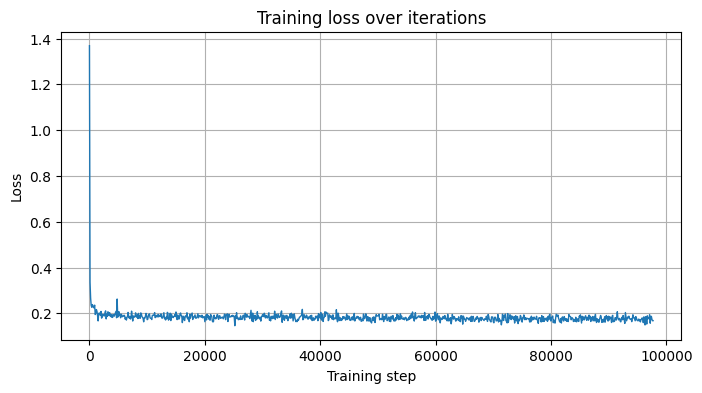

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(steps, losses, linewidth=1)
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Training loss over iterations")
plt.grid(True)
plt.show()


In [15]:
import re

log_path = "/content/drive/MyDrive/FM_coursework/Training_loss.txt"

times, losses = [], []

with open(log_path, "r") as f:
    for line in f:
        m = re.search(r"Loss:\s*([0-9.]+)\s*\|\s*LR:.*?\|\s*Time:\s*([0-9.]+)h", line)
        if m:
            loss = float(m.group(1))
            t = float(m.group(2)) # hours from start
            losses.append(loss)
            times.append(t)


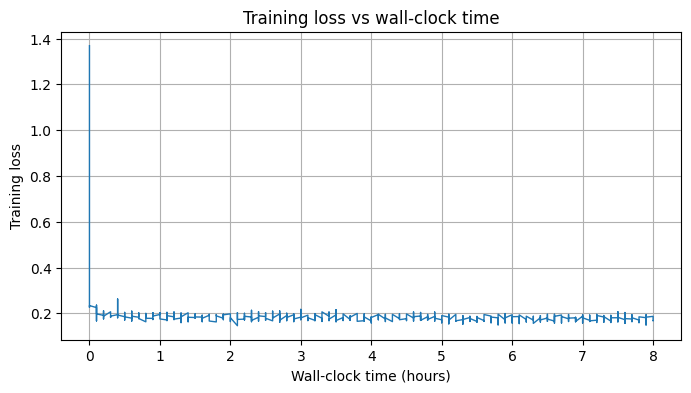

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(times, losses, linewidth=1)
plt.xlabel("Wall-clock time (hours)")
plt.ylabel("Training loss")
plt.title("Training loss vs wall-clock time")
plt.grid(True)
plt.show()


In [17]:
import re
from glob import glob

print("Loading final trained model...")

# Dynamically find the latest checkpoint
pattern = os.path.join(config.checkpoint_dir, "FM_step*.pt")
ckpts = glob(pattern)

def extract_step(path):
    match = re.search(r'FM_step(\d+)\.pt', path)
    return int(match.group(1)) if match else 0

if ckpts:
    final_model_path = max(ckpts, key=extract_step)
    print(f"Found and loading latest checkpoint: {final_model_path}")
    model = UNet(
        img_channels=config.img_channels,
        base_channels=config.base_channels,
        time_emb_dim=config.time_emb_dim,
        num_blocks=config.num_blocks,
        attention_resolutions=config.attention_resolutions
    ).to(device)
    checkpoint = torch.load(final_model_path, map_location=device)
    model.load_state_dict(checkpoint)
    model.eval()
    print("Final model loaded successfully.")
else:
    print(f"No checkpoints found in {config.checkpoint_dir}. Cannot load model.")
    model = None # Set model to None if no checkpoint is found

Loading final trained model...
Found and loading latest checkpoint: /content/drive/MyDrive/FM_coursework/checkpoints/FM_step100000.pt
Final model loaded successfully.


Generating samples...


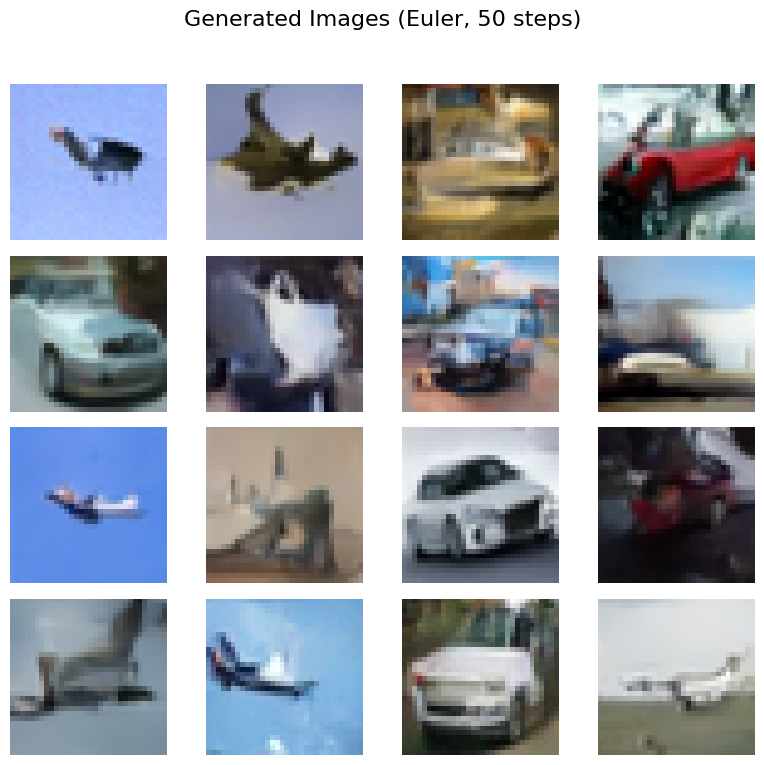

Sample generation complete and images saved.


In [24]:
print("Generating samples...")

# Re-initialize FlowMatching with the loaded model
# This ensures the `fm` instance uses the weights from the loaded checkpoint
fm_loaded = FlowMatching(model, device=device, config=config)

# Generate a batch of images using Euler sampling
num_samples_to_generate = 16 # You can adjust this number
num_sampling_steps = 50 # Number of steps for the ODE solver
generated_images = fm_loaded.sample_euler(batch_size=num_samples_to_generate, num_steps=num_sampling_steps)

# Move to CPU and convert to numpy for visualization
generated_images_np = generated_images.cpu().numpy()

# Convert images from [-1, 1] to [0, 1] for display
generated_images_np = (generated_images_np + 1) / 2

# Plot the generated images
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
axes = axes.flatten()

for i, img in enumerate(generated_images_np):
    # CIFAR-10 images are (C, H, W), matplotlib expects (H, W, C)
    axes[i].imshow(np.transpose(img, (1, 2, 0)))
    axes[i].axis('off')

plt.suptitle(f"Generated Images (Euler, {num_sampling_steps} steps)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save the generated images
plt.savefig(os.path.join(config.results_dir, 'generated_samples.png'))
plt.show()

print("Sample generation complete and images saved.")

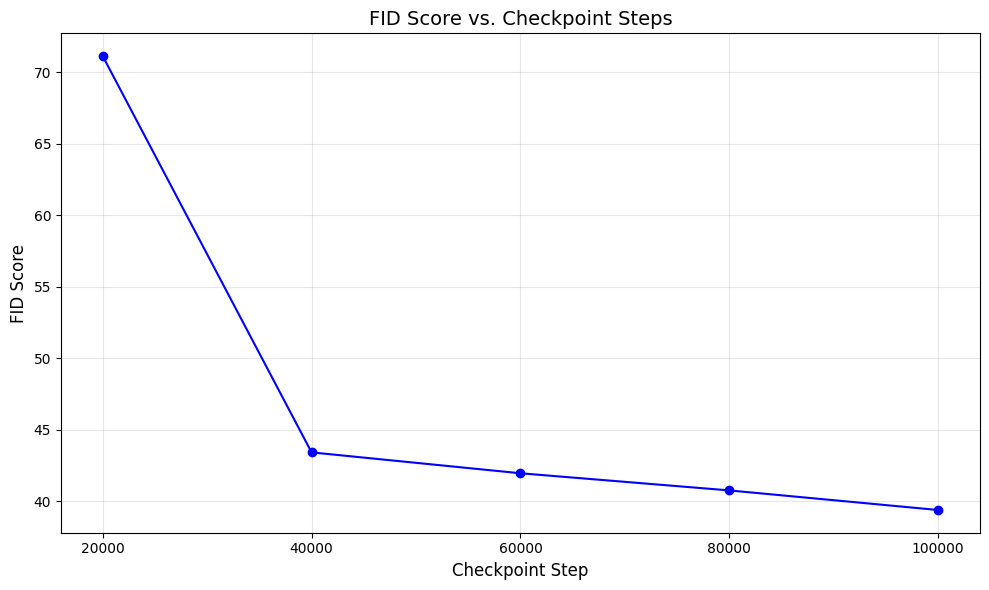

Plot of FID scores vs. checkpoint steps generated and saved.


In [25]:
import matplotlib.pyplot as plt
import os

# Extract steps and FID scores from the list of tuples
steps = [item[0] for item in fid_scores_at_checkpoints]
fid_scores = [item[1] for item in fid_scores_at_checkpoints]

plt.figure(figsize=(10, 6))
plt.plot(steps, fid_scores, marker='o', linestyle='-', color='b')
plt.xlabel('Checkpoint Step', fontsize=12)
plt.ylabel('FID Score', fontsize=12)
plt.title('FID Score vs. Checkpoint Steps', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(steps) # Ensure all checkpoint steps are shown on x-axis

plt.tight_layout()
plt.savefig(os.path.join(config.results_dir, 'fid_scores_vs_checkpoints.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Plot of FID scores vs. checkpoint steps generated and saved.")

In [20]:
import re

log_path = "/content/drive/MyDrive/FM_coursework/Training_loss.txt"

fid_steps, fid_scores = [], []

with open(log_path, "r") as f:
    for line in f:
        # e.g. "  Computing FID at step 20000..."
        m_step = re.search(r"Computing FID at step\s+(\d+)", line)
        if m_step:
            current_step = int(m_step.group(1))
        # e.g. "  FID (Euler 50 steps): 69.84"
        m_fid = re.search(r"FID \(Euler 50 steps\):\s*([0-9.]+)", line)
        if m_fid:
            fid_steps.append(current_step)
            fid_scores.append(float(m_fid.group(1)))


In [21]:
#Mapping Fid steps to times
step_times = {}

with open(log_path, "r") as f:
    for line in f:
        m = re.search(r"Step\s+(\d+)\s*\|.*Time:\s*([0-9.]+)h", line)
        if m:
            step = int(m.group(1))
            t = float(m.group(2))          # hours
            step_times[step] = t


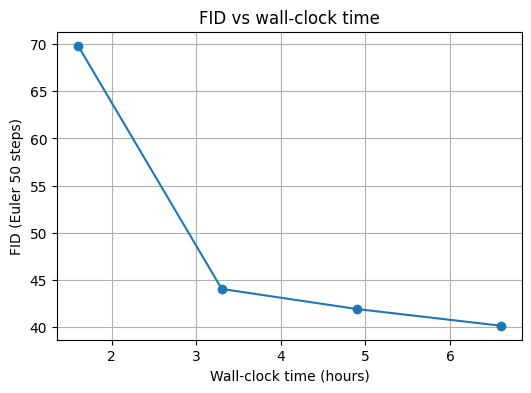

In [22]:
import numpy as np
import matplotlib.pyplot as plt

fid_times = []
for s in fid_steps:
    # use exact time if logged; otherwise nearest lower step
    if s in step_times:
        fid_times.append(step_times[s])
    else:
        lower_steps = [k for k in step_times.keys() if k <= s]
        fid_times.append(step_times[max(lower_steps)])

plt.figure(figsize=(6,4))
plt.plot(fid_times, fid_scores, marker="o")
plt.xlabel("Wall-clock time (hours)")
plt.ylabel("FID (Euler 50 steps)")
plt.title("FID vs wall-clock time")
plt.grid(True)
plt.show()


In [26]:
# Comparing  different ODE solvers

print("\n" + "="*60)
print("TASK 2: ODE Solver Comparison")
print("="*60)

# Getting 2k validation images for FID
val_data = np.load(os.path.join(config.validation_dir, 'val_images.npy'))
val_samples = torch.from_numpy(val_data).float()
val_samples = (val_samples.reshape(-1, 3, 32, 32) / 255.0 - 0.5) / 0.5

results = {}

for solver in ['euler', 'heun', 'rk4']:
    print(f"\n{solver.upper()} Method:")
    results[solver] = {'steps': [], 'fid': []}

    for num_steps in config.num_steps_list:
        print(f"  Evaluating with {num_steps} steps...", end=' ')

        # Generating 2k samples
        all_gen = []
        for _ in tqdm(range(config.fid_num_samples // config.fid_batch_size),
                     disable=True, leave=False):
            gen = fm_loaded.sample(batch_size=config.fid_batch_size, num_steps=num_steps, method=solver)
            all_gen.append(gen.cpu())

        gen_samples = torch.cat(all_gen, dim=0)
        fid_score = fid_calc.compute_fid(gen_samples.to(device), val_samples.to(device))

        results[solver]['steps'].append(num_steps)
        results[solver]['fid'].append(fid_score)

        print(f"FID = {fid_score:.2f}")

# Save results
with open(os.path.join(config.results_dir, 'ode_solver_results.json'), 'w') as f:
    json.dump(results, f, indent=2)

print("\nResults saved")


TASK 2: ODE Solver Comparison

EULER Method:
  Evaluating with 10 steps... 

KeyboardInterrupt: 

# New Section

In [28]:
# Calling ode results
import json
import os

results_path = os.path.join(config.results_dir, 'ode_solver_results.json')

if os.path.exists(results_path):
    print(f"Loading results from: {results_path}")
    with open(results_path, 'r') as f:
        results = json.load(f)

    print("\nODE Solver Results:")
    print(json.dumps(results, indent=2))
else:
    print(f"Results file not found at: {results_path}")
    print("\nYou need to run the ODE solver comparison first.")

Loading results from: /content/drive/MyDrive/FM_coursework/results/ode_solver_results.json

ODE Solver Results:
{
  "euler": {
    "steps": [
      10,
      20,
      50,
      100,
      500,
      1000
    ],
    "fid": [
      48.99529974456052,
      42.584979723232806,
      40.07206148803351,
      39.77954486309188,
      39.14563049358934,
      39.32787369115206
    ]
  },
  "heun": {
    "steps": [
      10,
      20,
      50,
      100,
      500,
      1000
    ],
    "fid": [
      71.97242005263499,
      50.56316235955901,
      41.480551147432735,
      40.789307599789325,
      39.73437596529632,
      40.51185316540014
    ]
  },
  "rk4": {
    "steps": [
      10,
      20,
      50,
      100,
      500,
      1000
    ],
    "fid": [
      43.24364119824924,
      39.667526307491784,
      40.46010800241709,
      39.29459362562896,
      40.14288065793973,
      40.17855763317376
    ]
  }
}


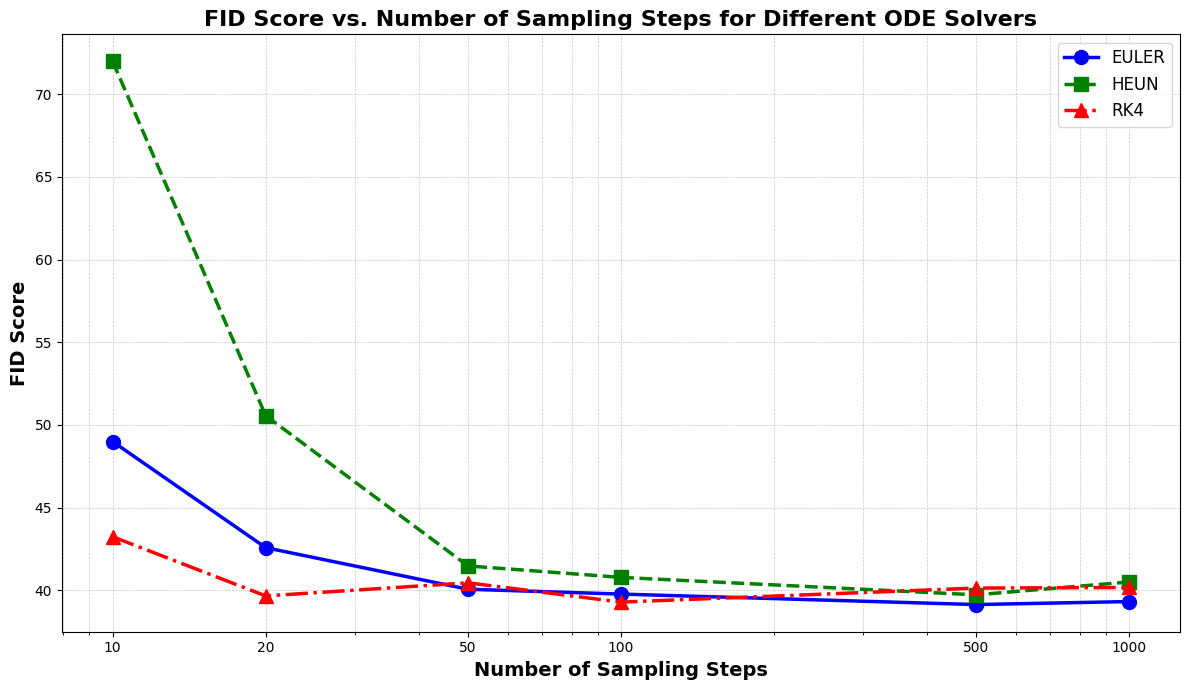


Plot saved to: /content/drive/MyDrive/FM_coursework/results/ode_solver_fid_comparison.png

Summary of Results:

EULER:
    10 steps: FID = 49.00
    20 steps: FID = 42.58
    50 steps: FID = 40.07
   100 steps: FID = 39.78
   500 steps: FID = 39.15
  1000 steps: FID = 39.33

HEUN:
    10 steps: FID = 71.97
    20 steps: FID = 50.56
    50 steps: FID = 41.48
   100 steps: FID = 40.79
   500 steps: FID = 39.73
  1000 steps: FID = 40.51

RK4:
    10 steps: FID = 43.24
    20 steps: FID = 39.67
    50 steps: FID = 40.46
   100 steps: FID = 39.29
   500 steps: FID = 40.14
  1000 steps: FID = 40.18


In [29]:
# Create comprehensive ODE solver comparison plot
import matplotlib.pyplot as plt
import json
import os

# Load the results
results_path = os.path.join(config.results_dir, 'ode_solver_results.json')
with open(results_path, 'r') as f:
    results = json.load(f)

# Define colors and styles for each solver
colors = {'euler': 'blue', 'heun': 'green', 'rk4': 'red'}
linestyles = {'euler': '-', 'heun': '--', 'rk4': '-.'}
markers = {'euler': 'o', 'heun': 's', 'rk4': '^'}

# Create the plot
plt.figure(figsize=(12, 7))

for solver in config.solvers:
    if solver in results:
        plt.plot(results[solver]['steps'], results[solver]['fid'],
                label=solver.upper(),
                color=colors[solver],
                linestyle=linestyles[solver],
                marker=markers[solver],
                linewidth=2.5,
                markersize=10)

plt.xlabel('Number of Sampling Steps', fontsize=14, fontweight='bold')
plt.ylabel('FID Score', fontsize=14, fontweight='bold')
plt.title('FID Score vs. Number of Sampling Steps for Different ODE Solvers',
          fontsize=16, fontweight='bold')
plt.xscale('log')  # Use log scale for better visualization
plt.xticks(config.num_steps_list, [str(s) for s in config.num_steps_list])
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(fontsize=12, loc='best')
plt.tight_layout()

# Save the plot
plot_path = os.path.join(config.results_dir, 'ode_solver_fid_comparison.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to: {plot_path}")
print("\nSummary of Results:")
for solver in config.solvers:
    if solver in results:
        print(f"\n{solver.upper()}:")
        for step, fid in zip(results[solver]['steps'], results[solver]['fid']):
            print(f"  {step:4d} steps: FID = {fid:.2f}")

In [30]:
# ==== TASK 3: IMPROVED INTEGRATION APPROXIMATION (IIA) - KNOWLEDGE DISTILLATION ====
print("KNOWLEDGE DISTILLATION WITH IMPROVED INTEGRATION APPROXIMATION")

import re
from glob import glob

# --- Ensure test_loader is defined for this cell ---
cifar_path = '/content/drive/MyDrive/cifar-10-batches-py'
_, _, temp_test_data, temp_test_labels = load_cifar10_subset(
    cifar_path, config.selected_classes
)
test_dataset = CIFAR10Dataset(temp_test_data, temp_test_labels)
test_loader = DataLoader(test_dataset, batch_size=config.fid_batch_size,
                        shuffle=False, num_workers=2, pin_memory=True)
# --------------------------------------------------

#Optimize per-step coefficients for low-step student solver to match high-step teacher. Based on ICLR 2024: "On Accelerating Diffusion-Based Sampling Processes via Improved Integration Approximation"
class IIA_Optimizer:


    def __init__(self, fm_instance, device, num_student_steps=10, num_teacher_steps=200):
        self.fm = fm_instance
        self.device = device
        self.num_student_steps = num_student_steps
        self.num_teacher_steps = num_teacher_steps

        # Per-step learnable coefficients for velocity corrections
        self.alpha_coeffs = torch.zeros(num_student_steps, 2, device=device, requires_grad=True) # Changed to requires_grad=True for optimization
        self.beta_coeffs = torch.zeros(num_student_steps, 2, device=device, requires_grad=True) # Changed to requires_grad=True for optimization

    # Compute accurate "teacher" update by running Heun with many sub-steps.Returns x_{t+1} after integrating from t_start to t_end.
    @torch.no_grad()
    def get_teacher_update(self, x_t, t_start, t_end, num_substeps=20):
        self.fm.ema_model.eval()
        x = x_t.clone()
        dt_total = t_end - t_start
        dt_sub = dt_total / num_substeps

        for s in range(num_substeps):
            t_curr = t_start + s * dt_sub
            t_next = t_curr + dt_sub
            t_curr_batch = torch.ones(x.shape[0], device=self.device) * t_curr
            t_next_batch = torch.ones(x.shape[0], device=self.device) * t_next

            v1 = self.fm.ema_model(x, t_curr_batch)
            x_pred = x + v1 * dt_sub
            v2 = self.fm.ema_model(x_pred, t_next_batch)
            x = x + (v1 + v2) * dt_sub / 2

        return x

    @torch.no_grad()
    def get_student_update_terms(self, x_t, t_start, t_end):
        """Get velocity estimates at start and end for coefficient learning."""
        t_start_batch = torch.ones(x_t.shape[0], device=self.device) * t_start
        t_end_batch = torch.ones(x_t.shape[0], device=self.device) * t_end

        v_start = self.fm.ema_model(x_t, t_start_batch)
        x_end_pred = x_t + v_start * (t_end - t_start)
        v_end = self.fm.ema_model(x_end_pred, t_end_batch)

        return v_start, v_end

    def optimize_coefficients(self, val_loader, num_batches=10):
        """Offline optimization per student step."""
        print("Optimizing IIA coefficients on validation set...")
        dt = 1.0 / self.num_student_steps

        # Optimizer for alpha_coeffs only
        alpha_optimizer = optim.Adam([self.alpha_coeffs], lr=1e-3) # Added an optimizer for the coefficients

        for step_idx in range(self.num_student_steps):
            # Reset alpha_coeffs for each step optimization to ensure independence
            # This assumes coefficients are optimized per-step independently as suggested by IIA literature
            self.alpha_coeffs.data.zero_()

            t_start = step_idx * dt
            t_end = (step_idx + 1) * dt
            mse_values = []

            for batch_idx, (x_batch, _) in enumerate(val_loader):
                if batch_idx >= num_batches:
                    break

                x_noise = torch.randn_like(x_batch).to(self.device)

                # Teacher reference
                x_teacher_next = self.get_teacher_update(x_noise, t_start, t_end, num_substeps=20)
                teacher_delta = x_teacher_next - x_noise

                # Student base update (Euler)
                v_start, v_end = self.get_student_update_terms(x_noise, t_start, t_end)
                base_delta = v_start * (t_end - t_start)

                # Correction term: alpha[step_idx, 0] * v_start + alpha[step_idx, 1] * v_end
                # Ensure requires_grad=True is set for alpha_coeffs
                correction = (
                    self.alpha_coeffs[step_idx, 0] * v_start +
                    self.alpha_coeffs[step_idx, 1] * v_end
                ) * (t_end - t_start)

                student_delta = base_delta + correction
                loss = F.mse_loss(student_delta, teacher_delta) # Compute loss

                alpha_optimizer.zero_grad() # Zero gradients for alpha_coeffs
                loss.backward() # Backpropagate
                alpha_optimizer.step() # Update alpha_coeffs

                mse_values.append(loss.item())

            avg_mse = np.mean(mse_values)
            if step_idx % 2 == 0:
                print(f"  Step {step_idx:2d}/{self.num_student_steps} | MSE: {avg_mse:.6f}")

        print("IIA coefficients optimized\n")

    @torch.no_grad()
    def sample_euler_iia(self, batch_size, img_size=32, channels=3):
        """Euler sampling with IIA-optimized coefficients."""
        self.fm.ema_model.eval()
        x = torch.randn(batch_size, channels, img_size, img_size, device=self.device)
        dt = 1.0 / self.num_student_steps

        for i in range(self.num_student_steps):
            t = torch.ones(batch_size, device=self.device) * (i * dt)
            t_next = torch.ones(batch_size, device=self.device) * ((i + 1) * dt)

            v_start = self.fm.ema_model(x, t)
            x_pred = x + v_start * dt
            v_end = self.fm.ema_model(x_pred, t_next)

            # Base Euler + IIA correction
            base_step = v_start * dt
            correction = (
                self.alpha_coeffs[i, 0] * v_start +
                self.alpha_coeffs[i, 1] * v_end
            ) * dt

            x = x + base_step + correction

        return x.clamp(-1, 1)


# Evaluate IIA for multiple student step counts
iia_results_all = {}

for num_student_steps in [10, 15, 20]:
    print(f"\n{'='*70}")
    print(f"IIA Optimization for {num_student_steps} Student Steps")
    print(f"{'='*70}")

    # Initialize IIA optimizer
    iia = IIA_Optimizer(fm_loaded, device=device, num_student_steps=num_student_steps, num_teacher_steps=200)

    # Optimize coefficients
    iia.optimize_coefficients(test_loader, num_batches=10)

    # Load validation data
    val_data_path = os.path.join(config.validation_dir, 'val_images.npy')
    val_data = np.load(val_data_path)
    val_samples = torch.from_numpy(val_data).float()
    val_samples = (val_samples.reshape(-1, 3, 32, 32) / 255.0 - 0.5) / 0.5

    # Baseline (regular Euler without IIA)
    print(f"Evaluating baseline Euler ({num_student_steps} steps)...")
    baseline_gen = []
    for _ in tqdm(range(config.fid_num_samples // config.fid_batch_size)):
        gen = fm_loaded.sample_euler(batch_size=config.fid_batch_size, num_steps=num_student_steps)
        baseline_gen.append(gen.cpu())

    baseline_samples = torch.cat(baseline_gen, dim=0)
    baseline_fid = fid_calc.compute_fid(baseline_samples.to(device), val_samples.to(device))

    # IIA-optimized Euler
    print(f"Evaluating IIA-Euler ({num_student_steps} steps)...")
    iia_gen = []
    for _ in tqdm(range(config.fid_num_samples // config.fid_batch_size)):
        gen = iia.sample_euler_iia(batch_size=config.fid_batch_size)
        iia_gen.append(gen.cpu())

    iia_samples = torch.cat(iia_gen, dim=0)
    iia_fid = fid_calc.compute_fid(iia_samples.to(device), val_samples.to(device))

    improvement = baseline_fid - iia_fid
    improvement_pct = (improvement / baseline_fid * 100) if baseline_fid > 0 else 0

    print(f"\nResults for {num_student_steps} steps:")
    print(f"  Baseline Euler: FID = {baseline_fid:.2f}")
    print(f"  IIA-Euler:      FID = {iia_fid:.2f}")
    print(f"  Improvement:    {improvement:.2f} FID points ({improvement_pct:.1f}%)\n")

    iia_results_all[num_student_steps] = {
        'baseline_fid': float(baseline_fid),
        'iia_fid': float(iia_fid),
        'improvement': float(improvement),
        'improvement_pct': float(improvement_pct),
    }

# Save IIA results
iia_path = os.path.join(config.results_dir, 'iia_results.json')
with open(iia_path, 'w') as f:
    json.dump(iia_results_all, f, indent=2)
print(f" IIA results saved to {iia_path}")

print("TASK 3 COMPLETE")

KNOWLEDGE DISTILLATION WITH IMPROVED INTEGRATION APPROXIMATION

IIA Optimization for 10 Student Steps
Optimizing IIA coefficients on validation set...
  Step  0/10 | MSE: 0.000217
  Step  2/10 | MSE: 0.000207
  Step  4/10 | MSE: 0.000204
  Step  6/10 | MSE: 0.000199
  Step  8/10 | MSE: 0.000201
IIA coefficients optimized

Evaluating baseline Euler (10 steps)...


100%|██████████| 20/20 [00:22<00:00,  1.13s/it]


Evaluating IIA-Euler (10 steps)...


100%|██████████| 20/20 [00:45<00:00,  2.27s/it]



Results for 10 steps:
  Baseline Euler: FID = 49.07
  IIA-Euler:      FID = 47.81
  Improvement:    1.26 FID points (2.6%)


IIA Optimization for 15 Student Steps
Optimizing IIA coefficients on validation set...
  Step  0/15 | MSE: 0.000042
  Step  2/15 | MSE: 0.000044
  Step  4/15 | MSE: 0.000041
  Step  6/15 | MSE: 0.000043
  Step  8/15 | MSE: 0.000043
  Step 10/15 | MSE: 0.000040
  Step 12/15 | MSE: 0.000042
  Step 14/15 | MSE: 0.000041
IIA coefficients optimized

Evaluating baseline Euler (15 steps)...


...


Results for 15 steps:
  Baseline Euler: FID = 44.41
  IIA-Euler:      FID = 43.67
  Improvement:    0.73 FID points (1.7%)


IIA Optimization for 20 Student Steps
Optimizing IIA coefficients on validation set...
  Step  0/20 | MSE: 0.000013
  Step  2/20 | MSE: 0.000012
  Step  4/20 | MSE: 0.000013
  Step  6/20 | MSE: 0.000013
  Step  8/20 | MSE: 0.000011
  Step 10/20 | MSE: 0.000012
  Step 12/20 | MSE: 0.000013
  Step 14/20 | MSE: 0.000012
  Step 16/20 | MSE: 0.000012
  Step 18/20 | MSE: 0.000013
IIA coefficients optimized

Evaluating baseline Euler (20 steps)...


100%|██████████| 20/20 [00:45<00:00,  2.27s/it]


Evaluating IIA-Euler (20 steps)...


100%|██████████| 20/20 [01:30<00:00,  4.54s/it]



Results for 20 steps:
  Baseline Euler: FID = 41.18
  IIA-Euler:      FID = 41.66
  Improvement:    -0.48 FID points (-1.2%)

 IIA results saved to /content/drive/MyDrive/FM_coursework/results/iia_results.json
TASK 3 COMPLETE


In [13]:
import json
import os

results_path = os.path.join(config.results_dir, 'iia_results.json')

if os.path.exists(results_path):
    print(f"Loading results from: {results_path}")
    with open(results_path, 'r') as f:
        results = json.load(f)

    print("\n IIA Results")
    print(json.dumps(results, indent=2))
else:
    print(f"Results file not found at: {results_path}")

Loading results from: /content/drive/MyDrive/FM_coursework/results/iia_results.json

 IIA Results
{
  "10": {
    "baseline_fid": 49.07373769029877,
    "iia_fid": 47.81208786983509,
    "improvement": 1.2616498204636812,
    "improvement_pct": 2.5709266908216217
  },
  "15": {
    "baseline_fid": 44.40559211406931,
    "iia_fid": 43.670925914954246,
    "improvement": 0.7346661991150611,
    "improvement_pct": 1.6544452266909242
  },
  "20": {
    "baseline_fid": 41.18485519977584,
    "iia_fid": 41.664115581388415,
    "improvement": -0.4792603816125762,
    "improvement_pct": -1.1636811135739644
  }
}


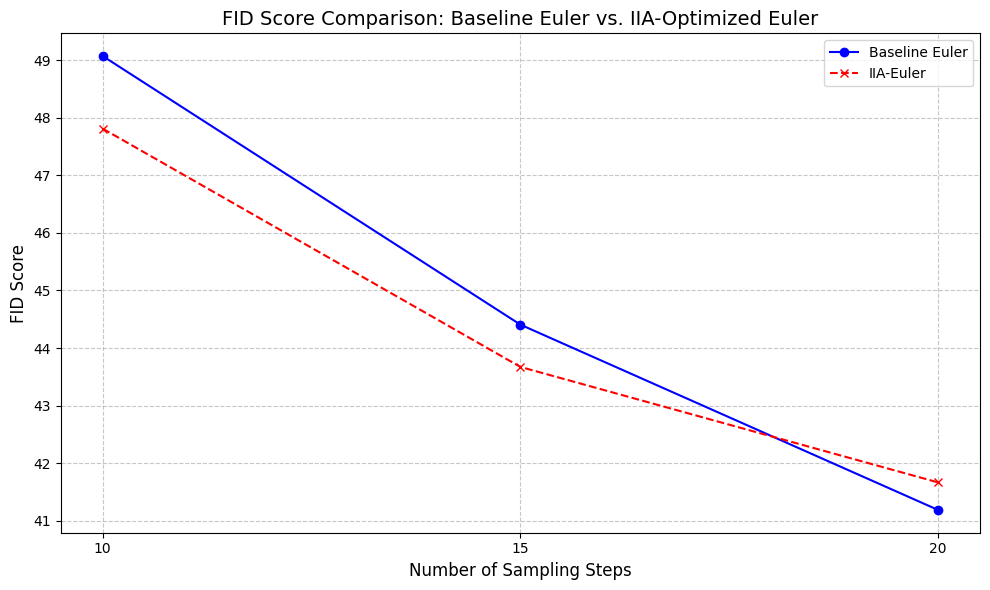

Plot saved to /content/drive/MyDrive/FM_coursework/results/iia_vs_baseline_euler_fid.png


In [14]:
import matplotlib.pyplot as plt
import json
import os

# Load the IIA results
results_path = os.path.join(config.results_dir, 'iia_results.json')
if os.path.exists(results_path):
    with open(results_path, 'r') as f:
        iia_results = json.load(f)
else:
    print(f"Error: IIA results file not found at {results_path}")
    # Fallback or exit if results are essential
    iia_results = {}

# Extract data for plotting
steps = []
baseline_fids = []
iia_fids = []

for num_steps_str, data in iia_results.items():
    num_steps = int(num_steps_str) # Convert string key to int
    steps.append(num_steps)
    baseline_fids.append(data['baseline_fid'])
    iia_fids.append(data['iia_fid'])

# Sort by steps to ensure correct plotting order
sorted_indices = sorted(range(len(steps)), key=lambda k: steps[k])
steps = [steps[i] for i in sorted_indices]
baseline_fids = [baseline_fids[i] for i in sorted_indices]
iia_fids = [iia_fids[i] for i in sorted_indices]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(steps, baseline_fids, marker='o', linestyle='-', color='blue', label='Baseline Euler')
plt.plot(steps, iia_fids, marker='x', linestyle='--', color='red', label='IIA-Euler')

plt.xlabel('Number of Sampling Steps', fontsize=12)
plt.ylabel('FID Score', fontsize=12)
plt.title('FID Score Comparison: Baseline Euler vs. IIA-Optimized Euler', fontsize=14)
plt.xticks(steps, [str(s) for s in steps]) # Ensure all step values are shown as x-ticks
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()

plot_path = os.path.join(config.results_dir, 'iia_vs_baseline_euler_fid.png')
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"Plot saved to {plot_path}")